In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2

# Path to converted dataset
DATASET_PATH = '/content/drive/MyDrive/RLMD_YOLO_Converted'
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
WORKING_DIR = '/content/drive/RLMD_training'

print("="*80)
print("YOLOV8 TRAINING - RLMD ROAD LINES")
print("="*80)
print(f"Dataset: {DATASET_PATH}")
print(f"Config: {YAML_PATH}")
print(f"Output: {WORKING_DIR}\n")

# Verify dataset exists
if not os.path.exists(YAML_PATH):
    print(" ERROR: Converted dataset not found!")
    print(f"   Please run the conversion script first.")
    exit()

# Check dataset structure
train_images = len(os.listdir(os.path.join(DATASET_PATH, 'images/train')))
val_images = len(os.listdir(os.path.join(DATASET_PATH, 'images/val')))
train_labels = len(os.listdir(os.path.join(DATASET_PATH, 'labels/train')))
val_labels = len(os.listdir(os.path.join(DATASET_PATH, 'labels/val')))

print(f" Dataset verified:")
print(f"   Train: {train_images} images, {train_labels} labels")
print(f"   Val: {val_images} images, {val_labels} labels\n")

YOLOV8 TRAINING - RLMD ROAD LINES
Dataset: /content/drive/MyDrive/RLMD_YOLO_Converted
Config: /content/drive/MyDrive/RLMD_YOLO_Converted/data.yaml
Output: /content/drive/RLMD_training

 Dataset verified:
   Train: 1389 images, 1388 labels
   Val: 348 images, 348 labels



In [ ]:
results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name='rlmd_road_lines',
    project=WORKING_DIR,
    patience=20,
    save=True,
    save_period=1,  # Save every epoch if improved
    device=0,
    workers=2,
    cache=False,
    verbose=True,
    plots=True,
    val=True,
    exist_ok=True
)

print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)

# Load best model
best_model_path = os.path.join(WORKING_DIR, 'rlmd_road_lines/weights/best.pt')
best_model = YOLO(best_model_path)

print(f"\nBest model: {best_model_path}")

# Validation
print("\nRunning validation...")
metrics = best_model.val()

print("\nPerformance Metrics:")
print(f"   Box mAP50: {metrics.box.map50:.4f}")
print(f"   Box mAP50-95: {metrics.box.map:.4f}")
print(f"   Mask mAP50: {metrics.seg.map50:.4f}")
print(f"   Mask mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RLMD_YOLO_Converted/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=bestV8.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rlmd_road_lines, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspe

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/RLMD_YOLO_Converted'
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
WORKING_DIR = '/content/drive/MyDrive/RLMD_training'

# Ensure the working directory exists
os.makedirs(WORKING_DIR, exist_ok=True)

model = YOLO(f'yolov8n-seg.pt')

results = model.train(
    data=YAML_PATH,
    epochs=200,
    imgsz=1280,  # or 1280 for more detail
    batch=BATCH_SIZE,
    name='rlmd_road_lines',
    project=WORKING_DIR,

    # Enhanced augmentation for road lines
    hsv_h=0.015,        # Hue augmentation
    hsv_s=0.7,          # Saturation augmentation
    hsv_v=0.4,          # Value augmentation
    degrees=10,         # Rotation (roads can have slight angles)
    translate=0.1,      # Translation
    scale=0.5,          # Scaling
    shear=0.0,          # Shear
    perspective=0.0001, # Perspective
    flipud=0.0,         # Don't flip roads upside down
    fliplr=0.5,         # Horizontal flip OK for roads
    mosaic=1.0,         # Mosaic augmentation
    mixup=0.1,          # Mix images
    copy_paste=0.1,     # Copy-paste augmentation

    # Optimized training params
    lr0=0.001,
    lrf=0.01,           # Final learning rate (lr0 * lrf)
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    optimizer='AdamW',
    dropout=0.0,        # Try without dropout first

    patience=30,        # More patience
    save_period=5,
    device=0,
    workers=4,          # Increase if you have CPU cores
    cache='ram',        # Cache in RAM for speed
    verbose=True,
    plots=True,
    val=True,
    exist_ok=True,
)

print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)

# Load best model
best_model_path = os.path.join(WORKING_DIR, 'rlmd_road_lines/weights/best.pt')
best_model = YOLO(best_model_path)

print(f"\nBest model: {best_model_path}")

# Validation
print("\n Running validation...")
metrics = best_model.val()

print("\n Performance Metrics:")
print(f"   Box mAP50: {metrics.box.map50:.4f}")
print(f"   Box mAP50-95: {metrics.box.map:.4f}")
print(f"   Mask mAP50: {metrics.seg.map50:.4f}")
print(f"   Mask mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RLMD_YOLO_Converted/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rlmd_road_lines, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, p

In [ ]:
from ultralytics import YOLO
import os

DATASET_PATH = '/content/drive/MyDrive/RLMD_YOLO_Converted'
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
WORKING_DIR = '/content/drive/MyDrive/RLMD_training'

# Ensure the working directory exists
os.makedirs(WORKING_DIR, exist_ok=True)

# Load previous checkpoint
model = YOLO('/content/drive/MyDrive/RLMD_training/rlmd_road_lines/weights/last.pt')  # or best.pt

# Resume training
results = model.train(
    data=YAML_PATH,
    project=WORKING_DIR,
    name='rlmd_road_lines',
    resume=True
)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RLMD_YOLO_Converted/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/RLMD_training/rlmd_road_lines/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rlmd_road_lines, nbs=64, nms=False, opset=None, optimize=Fal

Train Last.pt again

 DATASET ANALYSIS

 Total label files: 1388

 Objects per image:
  - Mean: 7.93
  - Median: 7.00
  - Min: 1
  - Max: 27
  - Std: 4.08

  Class Distribution:
Class                Count      Percentage
----------------------------------------
solid_single_white   2995        27.22%
dashed_single_white  2451        22.28%
solid_single_yellow  1050         9.54%
crosswalk            1007         9.15%
stop_line            645          5.86%
straight_arrow       605          5.50%
solid_single_red     518          4.71%
solid_double_yellow  460          4.18%
left_arrow           252          2.29%
motor_waiting_zone   241          2.19%
parking_lot          229          2.08%
left_turn_box        175          1.59%
left_straight_arrow  172          1.56%
right_arrow          72           0.65%
motor_icon           52           0.47%
motor_priority_lane  50           0.45%
dashed_single_yellow 27           0.25%

  POTENTIAL ISSUES DETECTED:
 SEVERE CLASS IMBALANCE: 110.9:1 ratio
   Most co

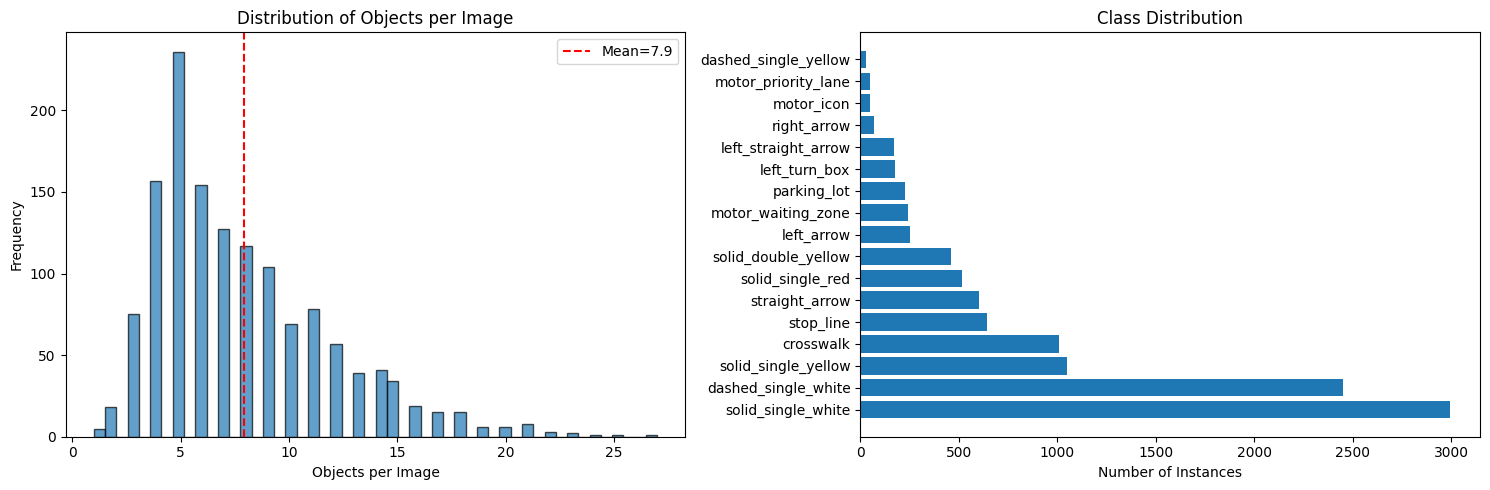

In [ ]:
import os
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# =============================================================================
# DATASET ANALYSIS - Find the Root Cause
# =============================================================================

dataset_path = '/content/drive/MyDrive/RLMD_YOLO_Converted/data.yaml'

dataset = '/content/drive/MyDrive/RLMD_YOLO_Converted'

# Load YAML
with open(dataset_path, 'r') as f:
    data = yaml.safe_load(f)

train_labels_path = Path(dataset) / 'labels' / 'train' # Corrected path for labels
class_names = data['names']

print("="*60)
print(" DATASET ANALYSIS")
print("="*60)

# Analyze class distribution
class_counts = Counter()
objs_per_image = [] # Renamed for clarity
image_sizes = [] # This variable is not used in the original code, but kept for consistency if it was intended for future use

label_files = list(train_labels_path.glob('*.txt'))
print(f"\n Total label files: {len(label_files)}")

for label_file in label_files:
    with open(label_file, 'r') as f:
        lines = f.readlines()
        objs_per_image.append(len(lines))

        for line in lines:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_counts[class_id] += 1

# Print statistics
print(f"\n Objects per image:")
print(f"  - Mean: {np.mean(objs_per_image):.2f}")
print(f"  - Median: {np.median(objs_per_image):.2f}")
print(f"  - Min: {np.min(objs_per_image)}")
print(f"  - Max: {np.max(objs_per_image)}")
print(f"  - Std: {np.std(objs_per_image):.2f}")

# Class distribution
print(f"\n  Class Distribution:")
print(f"{'Class':<20} {'Count':<10} {'Percentage':<10}")
print("-"*40)

total_objects = sum(class_counts.values())
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for class_id, count in sorted_classes:
    class_name = class_names[class_id] if class_id < len(class_names) else f"Class_{class_id}"
    percentage = (count / total_objects) * 100
    print(f"{class_name:<20} {count:<10} {percentage:>6.2f}%")

# Identify issues
print("\n" + "="*60)
print("  POTENTIAL ISSUES DETECTED:")
print("="*60)

# Check for severe imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count

if imbalance_ratio > 10:
    print(f" SEVERE CLASS IMBALANCE: {imbalance_ratio:.1f}:1 ratio")
    print(f"   Most common class has {max_count} instances")
    print(f"   Least common class has {min_count} instances")
    print(f"   → Solution: Use weighted loss or oversample rare classes")

# Check for variable object density
std_objects = np.std(objs_per_image)
if std_objects > 10:
    print(f"\n HIGH VARIANCE in objects per image (std={std_objects:.1f})")
    print(f"   Some images have {np.min(objs_per_image)}, others have {np.max(objs_per_image)}")
    print(f"   → Solution: Filter out extreme outliers or use auto-batch")

# Check for sparse dataset
avg_objects = np.mean(objs_per_image)
if avg_objects < 3:
    print(f"\n  LOW object density (avg={avg_objects:.2f} per image)")
    print(f"   → Solution: Add more training data or use stronger augmentation")

print("\n" + "="*60)
print(" RECOMMENDED FIXES:")
print("="*60)

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Objects per image histogram
axes[0].hist(objs_per_image, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Objects per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Objects per Image')
axes[0].axvline(np.mean(objs_per_image), color='red', linestyle='--', label=f'Mean={np.mean(objs_per_image):.1f}')
axes[0].legend()

# Plot 2: Class distribution
class_labels = [class_names[i] if i < len(class_names) else f"C{i}" for i, _ in sorted_classes]
class_values = [count for _, count in sorted_classes]
axes[1].barh(class_labels, class_values)
axes[1].set_xlabel('Number of Instances')
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('/content/dataset_analysis.png', dpi=150, bbox_inches='tight')
print("\n Analysis plot saved to: /content/dataset_analysis.png")

In [ ]:
# =============================================================================
# FIXED + IMPROVED SCRIPT — REMOVE RARE CLASSES + REMAP IDs
# =============================================================================

import os
import yaml
import shutil
from pathlib import Path
import time # Import time for sleep


CLASSES_TO_REMOVE = [10, 13, 19, 22,24]   # REMOVE THESE
IMAGE_EXTS = ['.jpg', '.jpeg', '.png', '.JPG']   # Supported image formats

dataset_path = '/content/drive/MyDrive/RLMD_YOLO_Converted'
output_path = '/content/drive/MyDrive/RLMD_YOLO_Converted_filter'

print(" Creating filtered dataset...")

# Create output folders
for split in ['train', 'val']:
    os.makedirs(f'{output_path}/{split}/images', exist_ok=True)
    os.makedirs(f'{output_path}/{split}/labels', exist_ok=True)

# Load YAML
with open(f'{dataset_path}/data.yaml', 'r') as f: # Corrected filename from rlmd_aug.yaml to data.yaml
    data = yaml.safe_load(f)

original_names = data['names']
print(f"\n Original classes: {len(original_names)}")

# Build class mapping
new_class_mapping = {}
new_names = []
new_idx = 0

print("\n🗑 Removing classes:")
for old_idx, name in enumerate(original_names):
    if old_idx in CLASSES_TO_REMOVE:
        print(f"    {old_idx}: {name}")
    else:
        new_class_mapping[old_idx] = new_idx
        new_names.append(name)
        new_idx += 1

print(f"\n New class count: {len(new_names)}")
print(f"✔ New classes: {new_names}")

# Log removed object counts
removed_class_counts = {cid: 0 for cid in CLASSES_TO_REMOVE}

# Process train + valid
for split in ['train', 'val']:
    print(f"\n Processing split: {split}")

    label_dir = Path(f'{dataset_path}/labels/{split}')
    image_dir = Path(f'{dataset_path}/images/{split}')

    # Corrected output directory paths to match the os.makedirs structure
    out_label_dir = Path(f'{output_path}/{split}/labels')
    out_image_dir = Path(f'{output_path}/{split}/images')

    kept_count = 0
    filtered_count = 0

    for label_file in label_dir.glob('*.txt'):

        new_lines = []

        if not label_file.exists():
            continue

        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if not parts:
                    continue

                class_id = int(parts[0])

                # Count removed classes
                if class_id in CLASSES_TO_REMOVE:
                    removed_class_counts[class_id] += 1
                    continue

                # Remap class
                new_class = new_class_mapping[class_id]
                parts[0] = str(new_class)
                new_lines.append(" ".join(parts) + "\n")

        # Skip files with no remaining objects
        if not new_lines:
            filtered_count += 1
            continue

        # Save label
        out_label_file = out_label_dir / label_file.name
        with open(out_label_file, 'w') as f:
            f.writelines(new_lines)

        # Copy corresponding image with retry logic
        copied = False
        for ext in IMAGE_EXTS:
            image_file = image_dir / label_file.with_suffix(ext).name
            if image_file.exists():
                # Retry mechanism for shutil.copy
                max_retries = 5
                retries = 0
                while retries < max_retries:
                    try:
                        shutil.copy(image_file, out_image_dir / image_file.name)
                        copied = True
                        break
                    except OSError as e:
                        print(f"\n      {e}. Retrying copy for {image_file.name} (attempt {retries + 1}/{max_retries})...")
                        retries += 1
                        time.sleep(2) # Wait for 2 seconds before retrying
                if copied:
                    break

        if copied:
            kept_count += 1
        else:
            print(f" Image not found or failed to copy for: {label_file.name}")

    print(f"\n Results for {split}:")
    print(f"    Kept images: {kept_count}")
    print(f"    Filtered (no valid objects): {filtered_count}")

# Create new YAML
new_data = {
    'path': output_path,
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(new_names),
    'names': new_names
}

with open(f'{output_path}/data.yaml', 'w') as f:
    yaml.dump(new_data, f, sort_keys=False)

print("\n Filtered dataset created successfully.")
print(" Saved at:", output_path)

print("\n Removed object counts:")
for cid in CLASSES_TO_REMOVE:
    print(f"   Class {cid} ({original_names[cid]}): {removed_class_counts[cid]}")

 Creating filtered dataset...

 Original classes: 25

🗑 Removing classes:
    10: dashed_single_yellow
    13: right_arrow
    19: motor_priority_lane
    22: motor_icon
    24: parking_lot

 New class count: 20
✔ New classes: ['background', 'box_junction', 'crosswalk', 'stop_line', 'solid_single_white', 'solid_single_yellow', 'solid_single_red', 'solid_double_white', 'solid_double_yellow', 'dashed_single_white', 'left_arrow', 'straight_arrow', 'left_straight_arrow', 'right_straight_arrow', 'channelizing_line', 'motor_prohibited', 'slow', 'motor_waiting_zone', 'left_turn_box', 'bike_icon']

 Processing split: train

 Results for train:
    Kept images: 1387
    Filtered (no valid objects): 1

 Processing split: val

 Results for val:
    Kept images: 347
    Filtered (no valid objects): 1

 Filtered dataset created successfully.
 Saved at: /content/drive/MyDrive/RLMD_YOLO_Converted_filter

 Removed object counts:
   Class 10 (dashed_single_yellow): 37
   Class 13 (right_arrow): 87
   C

In [ ]:
# Load previous checkpoint
DATASET_PATH = '/content/drive/MyDrive/RLMD_YOLO_Converted_filter'
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
WORKING_DIR = '/content/drive/MyDrive/RLMD_training'


# model = YOLO('yolov8n-seg.pt')
model = YOLO('/content/drive/MyDrive/RLMD_training/rlmd_road_lines_removed_classes/weights/last.pt')
results = model.train(
    data=YAML_PATH,
    epochs=300,
    imgsz=1280,
    batch=16,
    name='rlmd_road_lines_removed_classes',
    project=WORKING_DIR,
    lr0=0.0001,  # Lower initial learning rate
    patience=30,  # Increase patience to 30 epochs
    save=True,
    save_period=5,  # Save every epoch if improved
    device=0,
    workers=2,
    cache=False,
    verbose=True,
    plots=True,
    val=True,
    exist_ok=True,
    resume=True,
    degrees=10.0,     # Add rotation
    translate=0.2,    # More translation
    scale=0.9,        # More scaling
    shear=2.0,        # Add shear
    mixup=0.1,        # Add mixup augmentation
)

print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)

# Load best model
best_model_path = os.path.join(WORKING_DIR, 'rlmd_road_lines_again/weights/best.pt')
best_model = YOLO(best_model_path)

print(f"\n Best model: {best_model_path}")

# Validation
print("\n Running validation...")
metrics = best_model.val()

print("\n Performance Metrics:")
print(f"   Box mAP50: {metrics.box.map50:.4f}")
print(f"   Box mAP50-95: {metrics.box.map:.4f}")
print(f"   Mask mAP50: {metrics.seg.map50:.4f}")
print(f"   Mask mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RLMD_YOLO_Converted_filter/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/RLMD_training/rlmd_road_lines_removed_classes/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rlmd_road_lines_removed_classes,